In [1]:
import glob

import pandas as pd
import seaborn as sns
from sim_utils import eval_checkpoint, run_pca
from tqdm import tqdm

## Eval LIVI

In [2]:
results = dict()
for checkpoint in tqdm(glob.glob("../logs/sim/multiruns/**/last.ckpt", recursive=True)):
    results[checkpoint] = eval_checkpoint(checkpoint)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:44<00:00,  1.80it/s]


## Run PCA

In [3]:
results_pca = list()
for adata_path in tqdm(glob.glob("../data/simulated/*.h5ad")):
    results_pca += run_pca(adata_path)

  0%|                                                                                                                                                              | 0/8 [00:00<?, ?it/s]/data/heinent/miniconda3/envs/livi/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [04:58<00:00, 37.26s/it]


## Plot results

In [4]:
df = pd.DataFrame(results).T[["model", "power", "experiment", "param"]]
df = pd.concat([df, pd.DataFrame(results_pca)], axis=0).reset_index(drop=True)
df["param"] = df["param"].astype(float)
df["experiment"] = df["experiment"].replace(
    {"frac_var_celltypes": "FEV by celltypes", "frac_var_genetics": "FEV by genetics"}
)

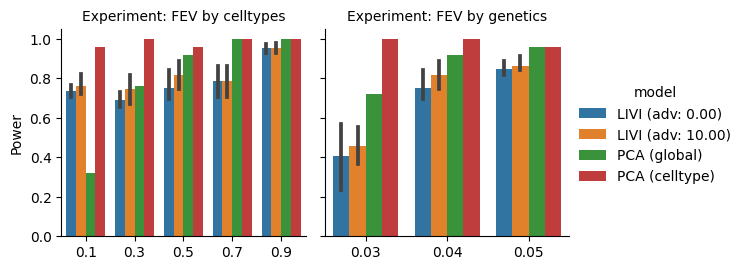

In [5]:
g = sns.catplot(
    x="param",
    y="power",
    hue="model",
    col="experiment",
    data=df,
    kind="bar",
    sharex=False,
    height=3,
)
g.set(xlabel="", ylabel="Power")
g.set_titles(col_template="Experiment: {col_name}")